# 🤖 Instagram Performance Analysis — Travel Mex Tours
## Notebook 03: Machine Learning — Performance Prediction

**Author:** Maria Garcia Sehara  
**Project:** Social Media Analytics — Travel Mex Tours  
**Platform:** Instagram  

---

### Objective
Build models to **predict Performance Score and Engagement Rate before publishing**.

### Key Improvement vs Previous Version
- **Primary target:** Performance Score (corrects reach bias)
- **Secondary target:** Engagement Rate (industry standard reference)
- Both predictions shown together in the predictor tool
- If Score is high but ER is low → post will have good reach but lower relative engagement
- If both are high → strong post across all dimensions

### Models
| Model | Why |
|-------|-----|
| Linear Regression | Simple baseline |
| Ridge Regression | Handles correlated features |
| Random Forest | Captures non-linear patterns |
| Gradient Boosting | Usually best performer |

### Metrics
- **R²** — Variance explained (higher = better, max 1.0)
- **MAE** — Average prediction error (lower = better)
- **CV R²** — 5-fold cross-validation R² (generalization check)


## 1. Setup & Data Load

In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../src")

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

BRAND_BLUE   = "#1877F2"
BRAND_PURPLE = "#833AB4"
BRAND_PINK   = "#E1306C"
PALETTE      = [BRAND_BLUE, BRAND_PURPLE, BRAND_PINK, "#FCAF45"]

RANDOM_STATE = 42
TEST_SIZE    = 0.20
FIGURES_PATH = Path("../../outputs/figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print("✅ Setup complete")


✅ Setup complete


In [2]:
from load_data import load_instagram_csv
from preprocessing import preprocess_df

DATA_DIR  = Path("../../data/instagram/")
csv_files = sorted(DATA_DIR.glob("*.csv"), key=lambda f: f.stat().st_mtime, reverse=True)
if not csv_files:
    raise FileNotFoundError("No CSV found in data/instagram/")

df_raw   = load_instagram_csv(csv_files[0])
df, meta = preprocess_df(df_raw)

er_col        = meta["engagement_rate_col"]
ps_col        = meta["performance_score_col"]
type_col      = meta.get("type_col")
time_slot_col = meta.get("time_slot_col")

print(f"✅ Data loaded → {len(df)} posts")
print(f"   Primary target   : {ps_col}  (Performance Score 0-100)")
print(f"   Secondary target : {er_col}  (Engagement Rate %)")
print(f"   Avg Score        : {meta['avg_performance_score']}/100")
print(f"   Avg ER           : {meta['avg_engagement_rate']}%")


✅ Loaded: InstagramData.csv  |  125 rows × 18 cols  |  UNKNOWN
✅ Preprocessing completed!
   → Date column            : publish_time
   → ER calculated via      : REACH
   → Avg ER                 : 15.36%
   → Avg Performance Score  : 30.25/100
   → vs Maximum Potential   : High=0 | Medium=46 | Low=79
   → vs Other Posts         : Above Avg=31 | Avg=60 | Below Avg=34
   → Time slots:
      🌅 Early Morning (6-9): 89 posts | avg ER 15.77%
      ☀️ Late Morning (10-12): 16 posts | avg ER 14.29%
      🌤️ Afternoon (13-17): 16 posts | avg ER 13.38%
✅ Data loaded → 125 posts
   Primary target   : performance_score  (Performance Score 0-100)
   Secondary target : engagement_rate_pct  (Engagement Rate %)
   Avg Score        : 30.25/100
   Avg ER           : 15.36%


## 2. Feature Selection

In [3]:
# Numeric features — interaction metrics
num_keys  = ["reach_col","views_col","likes_col","comments_col",
             "saves_col","shares_col","follows_col"]
num_feats = [meta[k] for k in num_keys if meta.get(k) and meta[k] in df.columns]

# Categorical features — content type + timing
cat_feats = []
if type_col and type_col in df.columns:             cat_feats.append(type_col)
if "weekday" in df.columns:                         cat_feats.append("weekday")
if time_slot_col and time_slot_col in df.columns:   cat_feats.append(time_slot_col)
if "month" in df.columns:                           cat_feats.append("month")

all_feats = num_feats + cat_feats

print(f"Numeric features     ({len(num_feats)}): {num_feats}")
print(f"Categorical features ({len(cat_feats)}): {cat_feats}")


Numeric features     (7): ['reach', 'views', 'likes', 'comments', 'saves', 'shares', 'follows']
Categorical features (4): ['post_type', 'weekday', 'time_slot', 'month']


In [4]:
# Build clean model dataset
model_df = df[all_feats + [ps_col, er_col]].dropna()

print(f"Total rows     : {len(df)}")
print(f"After dropna   : {len(model_df)}")
print(f"Rows dropped   : {len(df) - len(model_df)}")

if len(model_df) < 30:
    raise ValueError(f"Only {len(model_df)} complete rows — need ≥30 for reliable ML.")

X    = model_df[all_feats]
y_ps = model_df[ps_col]
y_er = model_df[er_col]

X_train, X_test, y_train_ps, y_test_ps = train_test_split(
    X, y_ps, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
_, _, y_train_er, y_test_er = train_test_split(
    X, y_er, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"\nTrain set : {len(X_train)} rows")
print(f"Test set  : {len(X_test)} rows  ({TEST_SIZE*100:.0f}%)")


Total rows     : 125
After dropna   : 121
Rows dropped   : 4

Train set : 96 rows
Test set  : 25 rows  (20%)


## 3. Preprocessing Pipeline

In [5]:
transformers = [("num", StandardScaler(), num_feats)]
if cat_feats:
    transformers.append(
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore",
                              sparse_output=False), cat_feats)
    )
preprocessor = ColumnTransformer(transformers, remainder="drop")

model_zoo = {
    "Linear Regression":  LinearRegression(),
    "Ridge Regression":   Ridge(alpha=1.0),
    "Random Forest":      RandomForestRegressor(
        n_estimators=400, max_depth=10, min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting":  GradientBoostingRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("✅ Pipeline ready")


✅ Pipeline ready


## 4. Train & Evaluate — Both Targets

In [6]:
def train_models(X, X_train, X_test, y_train, y_test, y_full,
                 model_zoo, preprocessor, cv, label):
    """Train all models for a given target. Returns results dict and pipelines dict."""
    results   = {}
    pipelines = {}

    print(f"Training models for {label}...\n")

    for name, model in model_zoo.items():
        pipe = Pipeline([("pre", preprocessor), ("model", model)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        cv_scores = cross_val_score(pipe, X, y_full, cv=cv, scoring="r2", n_jobs=-1)

        results[name] = {
            "R2":        round(float(r2_score(y_test, y_pred)), 4),
            "MAE":       round(float(mean_absolute_error(y_test, y_pred)), 4),
            "RMSE":      round(float(np.sqrt(mean_squared_error(y_test, y_pred))), 4),
            "CV_R2":     round(float(cv_scores.mean()), 4),
            "CV_R2_std": round(float(cv_scores.std()), 4),
        }
        pipelines[name] = pipe

        print(f"   {name}")
        print(f"      R²={results[name]['R2']}  "
              f"MAE=±{results[name]['MAE']}  "
              f"CV R²={results[name]['CV_R2']}±{results[name]['CV_R2_std']}")

    best = max(results, key=lambda x: results[x]["R2"])
    print(f"\n   ⭐ Best: {best}  (R²={results[best]['R2']})")
    return results, pipelines, best

# Train for Performance Score (primary)
results_ps, pipelines_ps, best_ps = train_models(
    X, X_train, X_test, y_train_ps, y_test_ps, y_ps,
    model_zoo, preprocessor, cv, "Performance Score"
)

print()

# Train for Engagement Rate (secondary)
results_er, pipelines_er, best_er = train_models(
    X, X_train, X_test, y_train_er, y_test_er, y_er,
    model_zoo, preprocessor, cv, "Engagement Rate"
)


Training models for Performance Score...

   Linear Regression
      R²=0.8837  MAE=±3.1245  CV R²=0.7536±0.0969
   Ridge Regression
      R²=0.8625  MAE=±3.4325  CV R²=0.7782±0.0614
   Random Forest
      R²=0.7968  MAE=±4.0789  CV R²=0.7499±0.1347
   Gradient Boosting
      R²=0.9035  MAE=±2.9148  CV R²=0.8923±0.0573

   ⭐ Best: Gradient Boosting  (R²=0.9035)

Training models for Engagement Rate...

   Linear Regression
      R²=0.7843  MAE=±3.005  CV R²=0.4604±0.206
   Ridge Regression
      R²=0.7464  MAE=±3.2892  CV R²=0.5048±0.1698
   Random Forest
      R²=0.7809  MAE=±3.0093  CV R²=0.715±0.15
   Gradient Boosting
      R²=0.8883  MAE=±2.1399  CV R²=0.8661±0.0847

   ⭐ Best: Gradient Boosting  (R²=0.8883)


## 5. Results Comparison

In [7]:
print("PERFORMANCE SCORE — Model Results:")
ps_df = (pd.DataFrame(results_ps).T
           .reset_index().rename(columns={"index":"Model"})
           .sort_values("R2", ascending=False))
display(ps_df.style
    .highlight_max(subset=["R2","CV_R2"], color="#c6efce")
    .highlight_min(subset=["MAE","RMSE"], color="#c6efce")
    .format(precision=4)
    .set_caption("Performance Score — Model Comparison"))

print("\nENGAGEMENT RATE — Model Results:")
er_df = (pd.DataFrame(results_er).T
           .reset_index().rename(columns={"index":"Model"})
           .sort_values("R2", ascending=False))
display(er_df.style
    .highlight_max(subset=["R2","CV_R2"], color="#c6efce")
    .highlight_min(subset=["MAE","RMSE"], color="#c6efce")
    .format(precision=4)
    .set_caption("Engagement Rate — Model Comparison"))


PERFORMANCE SCORE — Model Results:


,Model,R2,MAE,RMSE,CV_R2,CV_R2_std
3,Gradient Boosting,0.9035,2.9148,3.6448,0.8923,0.0573
0,Linear Regression,0.8837,3.1245,4.0021,0.7536,0.0969
1,Ridge Regression,0.8625,3.4325,4.3506,0.7782,0.0614
2,Random Forest,0.7968,4.0789,5.2891,0.7499,0.1347



ENGAGEMENT RATE — Model Results:


,Model,R2,MAE,RMSE,CV_R2,CV_R2_std
3,Gradient Boosting,0.8883,2.1399,2.7699,0.8661,0.0847
0,Linear Regression,0.7843,3.0050,3.8491,0.4604,0.2060
2,Random Forest,0.7809,3.0093,3.8792,0.7150,0.1500
1,Ridge Regression,0.7464,3.2892,4.1740,0.5048,0.1698


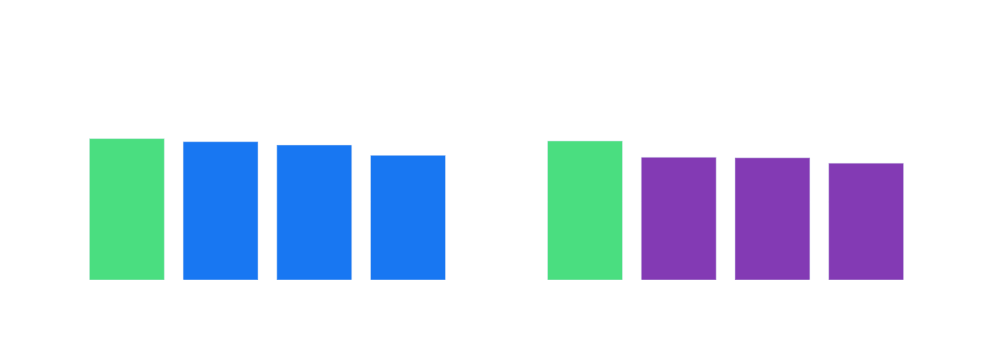

In [8]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=["R² — Performance Score Models",
                                    "R² — Engagement Rate Models"])

colors_ps = ["#4ade80" if m == best_ps else BRAND_BLUE for m in ps_df["Model"]]
colors_er = ["#4ade80" if m == best_er else BRAND_PURPLE for m in er_df["Model"]]

fig.add_trace(go.Bar(
    x=ps_df["Model"], y=ps_df["R2"],
    marker_color=colors_ps,
    text=ps_df["R2"].round(3), textposition="outside"
), row=1, col=1)

fig.add_trace(go.Bar(
    x=er_df["Model"], y=er_df["R2"],
    marker_color=colors_er,
    text=er_df["R2"].round(3), textposition="outside"
), row=1, col=2)

fig.update_layout(
    title="Model Comparison — Performance Score vs Engagement Rate",
    showlegend=False,
    yaxis=dict(range=[0, 1.15]),
    yaxis2=dict(range=[0, 1.15]),
    plot_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="rgba(0,0,0,0)",
    font_color="rgba(255,255,255,0.8)"
)
fig.show()


## 6. Feature Importance — What Drives Each Target?

In [9]:
def get_feature_importance(pipelines, best_model, num_feats, cat_feats):
    """Extract feature importance from best tree-based model."""
    for model_name in [best_model, "Gradient Boosting", "Random Forest"]:
        if model_name not in pipelines:
            continue
        pipe     = pipelines[model_name]
        fitted   = pipe.named_steps["pre"]
        num_names = num_feats.copy()
        try:
            ohe       = fitted.named_transformers_["cat"]
            cat_names = ohe.get_feature_names_out(cat_feats).tolist()
        except Exception:
            cat_names = []
        all_names   = num_names + cat_names
        importances = pipe.named_steps["model"].feature_importances_
        if len(importances) == len(all_names):
            fi = pd.DataFrame({"Feature": all_names, "Importance": importances})
            return fi.sort_values("Importance", ascending=False).round(4).reset_index(drop=True)
    return None

fi_ps = get_feature_importance(pipelines_ps, best_ps, num_feats, cat_feats)
fi_er = get_feature_importance(pipelines_er, best_er, num_feats, cat_feats)

if fi_ps is not None:
    print("Top 5 drivers of PERFORMANCE SCORE:")
    for _, row in fi_ps.head(5).iterrows():
        print(f"   {row['Feature']:30s}: {row['Importance']:.4f}")

print()

if fi_er is not None:
    print("Top 5 drivers of ENGAGEMENT RATE:")
    for _, row in fi_er.head(5).iterrows():
        print(f"   {row['Feature']:30s}: {row['Importance']:.4f}")

# Compare top features
if fi_ps is not None and fi_er is not None:
    top_ps = fi_ps.iloc[0]["Feature"]
    top_er = fi_er.iloc[0]["Feature"]
    print()
    if top_ps != top_er:
        print(f"⚠️  Top driver differs between targets:")
        print(f"   Performance Score → {top_ps}")
        print(f"   Engagement Rate   → {top_er}")
        print(f"   This means optimizing for ER alone may not maximize overall impact.")
    else:
        print(f"✅ Both targets share the same top driver: {top_ps}")


Top 5 drivers of PERFORMANCE SCORE:
   reach                         : 0.4813
   likes                         : 0.2967
   views                         : 0.0471
   shares                        : 0.0443
   saves                         : 0.0397

Top 5 drivers of ENGAGEMENT RATE:
   reach                         : 0.4813
   likes                         : 0.2967
   views                         : 0.0471
   shares                        : 0.0443
   saves                         : 0.0397

✅ Both targets share the same top driver: reach


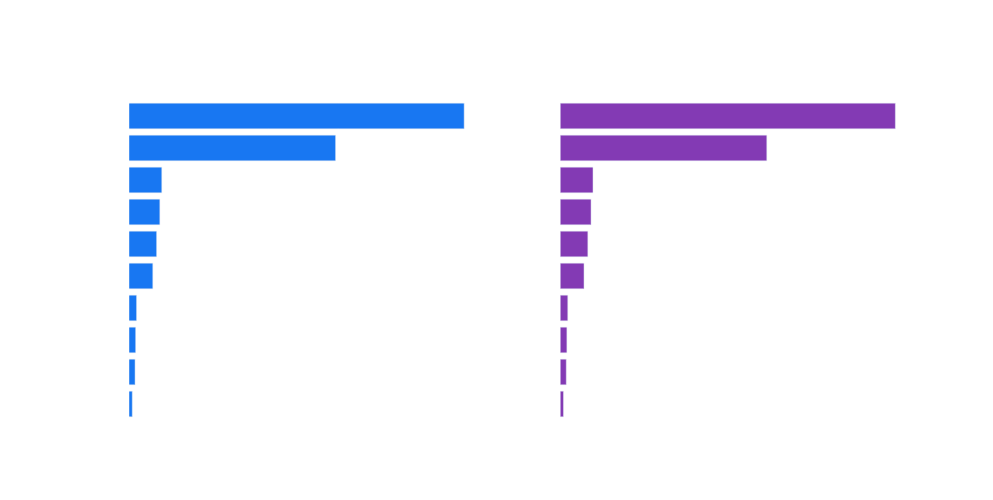

In [10]:
if fi_ps is not None and fi_er is not None:
    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=["Drives Performance Score",
                                        "Drives Engagement Rate"])

    top_ps = fi_ps.head(10)
    top_er = fi_er.head(10)

    fig.add_trace(go.Bar(
        x=top_ps["Importance"], y=top_ps["Feature"],
        orientation="h", marker_color=BRAND_BLUE,
        text=top_ps["Importance"].round(4), textposition="outside"
    ), row=1, col=1)

    fig.add_trace(go.Bar(
        x=top_er["Importance"], y=top_er["Feature"],
        orientation="h", marker_color=BRAND_PURPLE,
        text=top_er["Importance"].round(4), textposition="outside"
    ), row=1, col=2)

    fig.update_layout(
        title="Feature Importance — Performance Score vs Engagement Rate",
        showlegend=False,
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        font_color="rgba(255,255,255,0.8)",
        yaxis=dict(categoryorder="total ascending"),
        yaxis2=dict(categoryorder="total ascending"),
        height=500
    )
    fig.show()


## 7. Actual vs Predicted — Best Models

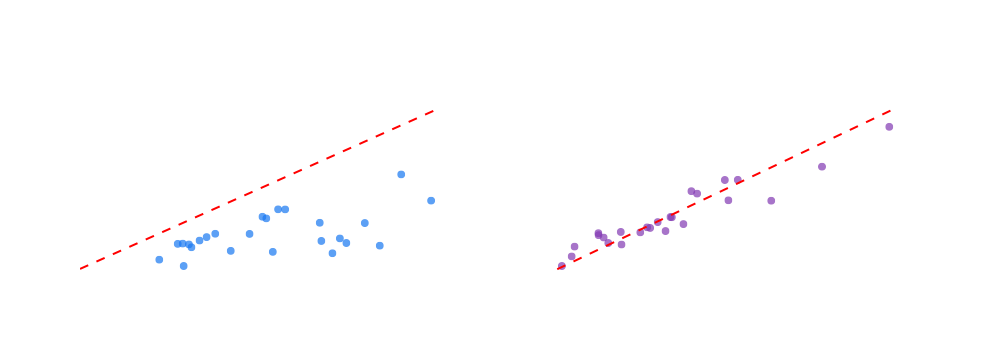

Performance Score model residuals → mean: 17.351 | std: 9.677
Engagement Rate model residuals   → mean: 0.218 | std: 2.761


In [11]:
y_pred_ps_best = pipelines_ps[best_ps].predict(X_test)
y_pred_er_best = pipelines_er[best_er].predict(X_test)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=[f"Performance Score — {best_ps}",
                                    f"Engagement Rate — {best_er}"])

lims_ps = [min(y_test_ps.min(), y_pred_ps_best.min()) - 1,
            max(y_test_ps.max(), y_pred_ps_best.max()) + 1]
lims_er = [min(y_test_er.min(), y_pred_er_best.min()) - 0.5,
            max(y_test_er.max(), y_pred_er_best.max()) + 0.5]

fig.add_trace(go.Scatter(
    x=y_test_ps.values, y=y_pred_ps_best,
    mode="markers", marker=dict(color=BRAND_BLUE, size=8, opacity=0.7),
    name="Posts"
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=lims_ps, y=lims_ps, mode="lines",
    line=dict(color="red", dash="dash"), name="Perfect"
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=y_test_er.values, y=y_pred_er_best,
    mode="markers", marker=dict(color=BRAND_PURPLE, size=8, opacity=0.7),
    name="Posts"
), row=1, col=2)
fig.add_trace(go.Scatter(
    x=lims_er, y=lims_er, mode="lines",
    line=dict(color="red", dash="dash"), name="Perfect"
), row=1, col=2)

fig.update_layout(
    title="Actual vs Predicted — Performance Score & Engagement Rate",
    showlegend=False,
    plot_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="rgba(0,0,0,0)",
    font_color="rgba(255,255,255,0.8)"
)
fig.update_xaxes(title_text="Actual", row=1, col=1)
fig.update_xaxes(title_text="Actual", row=1, col=2)
fig.update_yaxes(title_text="Predicted", row=1, col=1)
fig.update_yaxes(title_text="Predicted", row=1, col=2)
fig.show()

print(f"Performance Score model residuals → mean: {(y_test_ps.values - y_pred_ps_best).mean():.3f} | std: {(y_test_ps.values - y_pred_ps_best).std():.3f}")
print(f"Engagement Rate model residuals   → mean: {(y_test_er.values - y_pred_er_best).mean():.3f} | std: {(y_test_er.values - y_pred_er_best).std():.3f}")


## 8. 🚀 Predict Performance Before Publishing

Fill in the details of your next post and the model will predict both
**Performance Score** and **Engagement Rate** before you publish.

**How to interpret the two predictions:**
- **Both high** → Strong post across all dimensions — boost it!
- **Score high, ER low** → Good absolute impact but lower engagement rate — post is reaching many people
- **ER high, Score low** → Good engagement quality but limited reach — boost to amplify
- **Both low** → Reconsider content before publishing


In [12]:
# ── Fill in your post details here ────────────────────────────────────────
new_post = {}

# Numeric — estimated values before publishing
col_map = {
    "reach":    meta.get("reach_col"),
    "views":    meta.get("views_col"),
    "likes":    meta.get("likes_col"),
    "comments": meta.get("comments_col"),
    "saves":    meta.get("saves_col"),
    "shares":   meta.get("shares_col"),
    "follows":  meta.get("follows_col"),
}

# Default to median values as starting point
print("Default values (your historical medians):")
for label, col in col_map.items():
    if col and col in df.columns:
        median_val = int(df[col].median())
        new_post[col] = median_val
        print(f"   {label:12s} ({col:15s}): {median_val}")

# ── Categorical — change these to your planned post details ───────────────
if type_col and type_col in cat_feats:
    options = df[type_col].dropna().unique().tolist()
    new_post[type_col] = options[0]          # ← change to your content type
    print(f"   post_type    : {options[0]}  (options: {options})")

if "weekday" in cat_feats:
    best_day = df.groupby("weekday")[ps_col].mean().idxmax()
    new_post["weekday"] = best_day           # ← change to your planned day
    print(f"   weekday      : {best_day}  (your best day by Score)")

if time_slot_col and time_slot_col in cat_feats:
    best_slot = df.groupby(time_slot_col, observed=True)[ps_col].mean().idxmax()
    new_post[time_slot_col] = best_slot      # ← change to your planned slot
    print(f"   time_slot    : {best_slot}  (your best slot by Score)")

if "month" in cat_feats:
    new_post["month"] = df["month"].mode()[0]
    print(f"   month        : {new_post['month']}")


Default values (your historical medians):
   reach        (reach          ): 31
   views        (views          ): 84
   likes        (likes          ): 4
   comments     (comments       ): 0
   saves        (saves          ): 0
   shares       (shares         ): 0
   follows      (follows        ): 0
   post_type    : IG reel  (options: ['IG reel', 'IG carousel', 'IG image', 'Post type'])
   weekday      : Tuesday  (your best day by Score)
   time_slot    : ☀️ Late Morning (10-12)  (your best slot by Score)
   month        : June


In [13]:
# ── Run prediction ────────────────────────────────────────────────────────
new_df = pd.DataFrame([new_post])

pred_ps = max(0, pipelines_ps[best_ps].predict(new_df)[0])
pred_er = max(0, pipelines_er[best_er].predict(new_df)[0])

avg_ps  = df[ps_col].mean()
avg_er  = df[er_col].mean()
BENCHMARK_ER = 5.0

print("=" * 60)
print("  PREDICTION RESULTS")
print("=" * 60)
print(f"\n  📊 Performance Score  : {pred_ps:.1f} / 100")
print(f"     Your avg Score     : {avg_ps:.1f} / 100")
print(f"     vs your avg        : {'✅ Above' if pred_ps >= avg_ps else '⚠️  Below'} ({pred_ps - avg_ps:+.1f} points)")

print(f"\n  📈 Engagement Rate    : {pred_er:.2f}%")
print(f"     Your avg ER        : {avg_er:.2f}%")
print(f"     Industry benchmark : {BENCHMARK_ER}%")
print(f"     vs your avg        : {'✅ Above' if pred_er >= avg_er else '⚠️  Below'} ({pred_er - avg_er:+.2f}%)")

# Interpretation
print(f"\n  💡 INTERPRETATION:")
if pred_ps >= avg_ps and pred_er >= avg_er:
    print(f"     🔥 Strong post — high Score AND high ER.")
    print(f"        Publish and consider boosting to maximize reach!")
elif pred_ps >= avg_ps and pred_er < avg_er:
    print(f"     📢 Good absolute impact but lower engagement rate.")
    print(f"        Post will reach many people — add a strong CTA to drive interactions.")
elif pred_ps < avg_ps and pred_er >= avg_er:
    print(f"     🎯 Good engagement quality but limited reach.")
    print(f"        Consider boosting to amplify this content to more people.")
else:
    print(f"     ⚠️  Below average on both metrics.")
    print(f"        Review content type, posting time, or caption before publishing.")

print("=" * 60)
print(f"\nModel used (Score): {best_ps}  (R²={results_ps[best_ps]['R2']})")
print(f"Model used (ER)   : {best_er}  (R²={results_er[best_er]['R2']})")
print(f"\n⚠️  Note: Model trained on {len(model_df)} posts.")
print(f"   Predictions improve as more data is added each month.")


  PREDICTION RESULTS

  📊 Performance Score  : 12.6 / 100
     Your avg Score     : 30.2 / 100
     vs your avg        : ⚠️  Below (-17.6 points)

  📈 Engagement Rate    : 12.63%
     Your avg ER        : 15.36%
     Industry benchmark : 5.0%
     vs your avg        : ⚠️  Below (-2.73%)

  💡 INTERPRETATION:
     ⚠️  Below average on both metrics.
        Review content type, posting time, or caption before publishing.

Model used (Score): Gradient Boosting  (R²=0.9035)
Model used (ER)   : Gradient Boosting  (R²=0.8883)

⚠️  Note: Model trained on 121 posts.
   Predictions improve as more data is added each month.


In [14]:
# ── Sensitivity analysis — what if we change one variable? ────────────────
# This shows how sensitive the prediction is to each input
print("SENSITIVITY ANALYSIS — Impact of changing each input by +50%:\n")

base_ps = pipelines_ps[best_ps].predict(new_df)[0]

for col in num_feats:
    if col not in new_post:
        continue
    modified = new_post.copy()
    modified[col] = new_post[col] * 1.5   # increase by 50%
    mod_df  = pd.DataFrame([modified])
    mod_ps  = pipelines_ps[best_ps].predict(mod_df)[0]
    delta   = mod_ps - base_ps
    print(f"   +50% {col:20s} → Score change: {delta:+.2f} points")


SENSITIVITY ANALYSIS — Impact of changing each input by +50%:

   +50% reach                → Score change: -2.49 points
   +50% views                → Score change: +0.39 points
   +50% likes                → Score change: +4.53 points
   +50% comments             → Score change: +0.00 points
   +50% saves                → Score change: +0.00 points
   +50% shares               → Score change: +0.00 points
   +50% follows              → Score change: +0.00 points


## 9. Executive Summary

In [15]:
bm_ps = results_ps[best_ps]
bm_er = results_er[best_er]

print("=" * 65)
print("  MACHINE LEARNING SUMMARY — TRAVEL MEX TOURS")
print("=" * 65)

print(f"\n🏆 PRIMARY MODEL (Performance Score)")
print(f"   Best model   : {best_ps}")
print(f"   R²           : {bm_ps['R2']}  ({bm_ps['R2']*100:.0f}% of variance explained)")
print(f"   MAE          : ±{bm_ps['MAE']} points")
print(f"   CV R²        : {bm_ps['CV_R2']} ± {bm_ps['CV_R2_std']}  (generalization)")

print(f"\n📊 SECONDARY MODEL (Engagement Rate)")
print(f"   Best model   : {best_er}")
print(f"   R²           : {bm_er['R2']}  ({bm_er['R2']*100:.0f}% of variance explained)")
print(f"   MAE          : ±{bm_er['MAE']}%")
print(f"   CV R²        : {bm_er['CV_R2']} ± {bm_er['CV_R2_std']}")

if fi_ps is not None:
    print(f"\n🔑 TOP 3 DRIVERS OF PERFORMANCE SCORE:")
    for _, row in fi_ps.head(3).iterrows():
        print(f"   {_+1}. {row['Feature']:25s}: {row['Importance']:.4f}")

print(f"\n⚠️  MODEL LIMITATIONS:")
print(f"   • Trained on {len(model_df)} posts — predictions improve with more data")
print(f"   • Re-train monthly as new posts are published")
print(f"   • Sensitivity analysis shows which inputs matter most")

print(f"\n🎯 HOW TO USE THIS MODEL:")
print(f"   1. Before publishing → fill in Section 8 with planned post details")
print(f"   2. If Score < {avg_ps:.0f} (your avg) → adjust content type, timing, or CTA")
print(f"   3. If Score ≥ {avg_ps:.0f} AND ER ≥ {avg_er:.1f}% → publish and boost")
print(f"   4. Upload new data monthly to keep model current")
print("=" * 65)
print("\n→ Next: Notebook 04 — Content Strategy")


  MACHINE LEARNING SUMMARY — TRAVEL MEX TOURS

🏆 PRIMARY MODEL (Performance Score)
   Best model   : Gradient Boosting
   R²           : 0.9035  (90% of variance explained)
   MAE          : ±2.9148 points
   CV R²        : 0.8923 ± 0.0573  (generalization)

📊 SECONDARY MODEL (Engagement Rate)
   Best model   : Gradient Boosting
   R²           : 0.8883  (89% of variance explained)
   MAE          : ±2.1399%
   CV R²        : 0.8661 ± 0.0847

🔑 TOP 3 DRIVERS OF PERFORMANCE SCORE:
   1. reach                    : 0.4813
   2. likes                    : 0.2967
   3. views                    : 0.0471

⚠️  MODEL LIMITATIONS:
   • Trained on 121 posts — predictions improve with more data
   • Re-train monthly as new posts are published
   • Sensitivity analysis shows which inputs matter most

🎯 HOW TO USE THIS MODEL:
   1. Before publishing → fill in Section 8 with planned post details
   2. If Score < 30 (your avg) → adjust content type, timing, or CTA
   3. If Score ≥ 30 AND ER ≥ 15.4% → 